### Environment Setup and Library Imports

In [1]:
from pathlib import Path
import sys
print(sys.executable)

import json
from collections import Counter
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

import random
import os
import shutil
import orjson

c:\Users\paude\OneDrive\Documents\@Schools_Learning\@HarvardExtension\2026FALL\CSCIE115APDS26FA\converter-iq-mlops\.venv\Scripts\python.exe


### Project Path Resolution and Data Directory Initialization

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
DATA_DIR = PROJECT_ROOT / "ml" / "data"
INPUT_FILE = DATA_DIR / "raw" / "id_mea_2.json"
RECORDS_DIR = DATA_DIR / "raw_records"
RECORDS_DIR.mkdir(parents=True, exist_ok=True)

EPISODES_DIR = DATA_DIR / "raw_episodes"
EPISODES_DIR.mkdir(parents=True, exist_ok=True)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("DATA_DIR:", DATA_DIR)
print("RECORDS_DIR:", RECORDS_DIR)
print("EPISODES_DIR:", EPISODES_DIR)



PROJECT_ROOT: c:\Users\paude\OneDrive\Documents\@Schools_Learning\@HarvardExtension\2026FALL\CSCIE115APDS26FA\converter-iq-mlops
NOTEBOOK_DIR: c:\Users\paude\OneDrive\Documents\@Schools_Learning\@HarvardExtension\2026FALL\CSCIE115APDS26FA\converter-iq-mlops\ml\notebooks
DATA_DIR: c:\Users\paude\OneDrive\Documents\@Schools_Learning\@HarvardExtension\2026FALL\CSCIE115APDS26FA\converter-iq-mlops\ml\data
RECORDS_DIR: c:\Users\paude\OneDrive\Documents\@Schools_Learning\@HarvardExtension\2026FALL\CSCIE115APDS26FA\converter-iq-mlops\ml\data\raw_records
EPISODES_DIR: c:\Users\paude\OneDrive\Documents\@Schools_Learning\@HarvardExtension\2026FALL\CSCIE115APDS26FA\converter-iq-mlops\ml\data\raw_episodes


### Fault Category Record Counts in Full JSON Dataset (`id_mea_2.json`)

In [3]:
# Load the giant JSON file
with open(INPUT_FILE, "r") as f:
    records = json.load(f)

# Count id_error values
counts = Counter(rc["id_error"] for rc in records)

# Convert to a DataFrame
df = pd.DataFrame(
    sorted(counts.items()),      # ensures id_error is sorted
    columns=["id_error", "count"]
)

print(df)


    id_error   count
0          0  277041
1          1    2388
2          2    2265
3          3    2306
4          4    2333
5          5    2424
6          6    2375
7          7    2272
8          8    2300
9          9    2202
10        10    2294
11        11    2218
12        12    2445
13        13    2666
14        14    2512
15        15    2578
16        16    2552
17        17    2571
18        18    2631
19        19    2541
20        20    2702
21        21    2654
22        22    2661
23        23    2499
24        24    2494
25        25    2698
26        26    2566
27        27    2588
28        28    2546
29        29    2397
30        30    2277
31        31    2238
32        32    2216
33        33    2312
34        34    2281
35        35    2223
36        36    2326
37        37    2300
38        38    2104
39        39    1989
40        40    2007
41        41    1936
42        42    1959
43        43    1868
44        44    2022
45        45    1967
46        46 

### Manual or Auto Record Selection and Three‑Phase Visualization

Selected record_number: 0
id_error: 0
Length: 60
First 15 samples: [ 1357.48718262   836.62219238   198.27580261  -433.45697021
 -1021.69415283 -1487.88562012 -1827.92773438 -1999.29748535
 -1964.67578125 -1742.7232666  -1340.88623047  -824.18884277
  -205.68986511   418.98550415  1010.67987061]


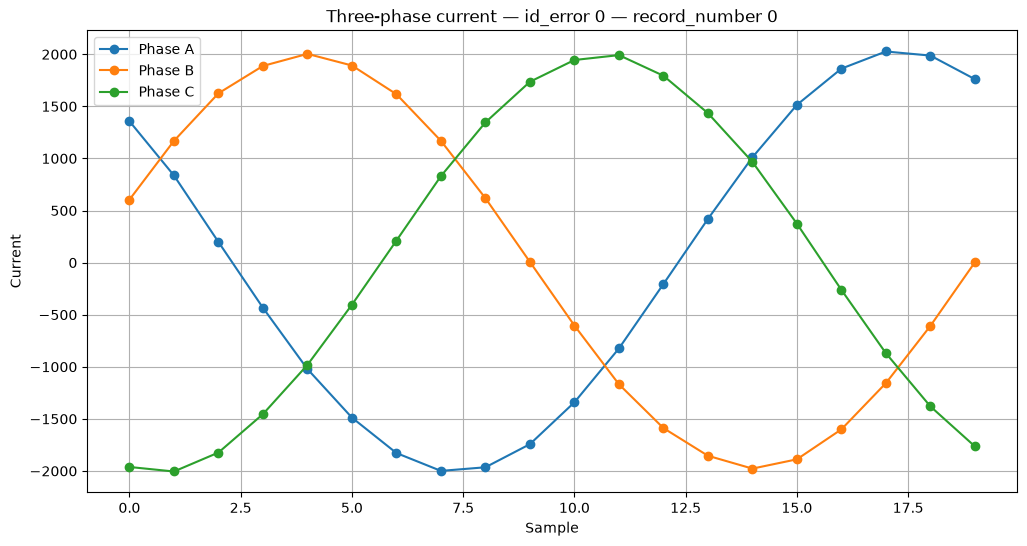

In [4]:
AUTO_MODE = True          # Set to True for default input (default=0), False when you want manual input 

#========================================================
# Step 1 — Load the large JSON file once
#========================================================
with open(INPUT_FILE, "r") as f:
    records = json.load(f)

#========================================================
# Step 2 — Ask user for record_number
#========================================================
if AUTO_MODE:
    RC_NUMBER = 0
else:
    user_input = input("Enter record_number (default = 0): ").strip()
    RC_NUMBER = int(user_input) if user_input else 0


# Safety check
if RC_NUMBER < 0 or RC_NUMBER >= len(records):
    print(f"record_number {RC_NUMBER} is out of range (0 to {len(records)-1})")
    exit()

# Load the specific record
record = records[RC_NUMBER]

print("Selected record_number:", RC_NUMBER)
print("id_error:", record["id_error"])

#========================================================
# Step 3 — Extract raw samples
#========================================================
raw = np.array(record["mea_value"])
print("Length:", len(raw))
print("First 15 samples:", raw[:15])

#========================================================
# Step 4 — Extract the three phases
#========================================================
INTERLEAVED = False

if INTERLEAVED:
    phases = raw.reshape(-1, 3).T
    phaseA, phaseB, phaseC = phases
else:
    N = len(raw) // 3
    phaseA = raw[0:N]
    phaseB = raw[N:2*N]
    phaseC = raw[2*N:3*N]

#========================================================
# Step 5 — Plot
#========================================================
plt.figure(figsize=(12, 6))

plt.plot(phaseA, label="Phase A", marker="o", markevery=1)
plt.plot(phaseB, label="Phase B", marker="o", markevery=1)
plt.plot(phaseC, label="Phase C", marker="o", markevery=1)

plt.title(
    f"Three-phase current — id_error {record['id_error']} — record_number {RC_NUMBER}"
)
plt.xlabel("Sample")
plt.ylabel("Current")
plt.grid(True)
plt.legend()
plt.show()


### Random `id_error` Record Selection and Three‑Phase Visualization

record_number: 57389
Selected id_error: 0
Length: 60
First 15 samples: [-6158.85107422 -4969.5390625  -3853.56323242 -2333.02978516
  -445.1022644   1466.40075684  3336.68139648  4341.85253906
  5246.06396484  6072.78271484  5933.89404297  4957.09570312
  3844.1472168   2403.85083008   441.97122192]


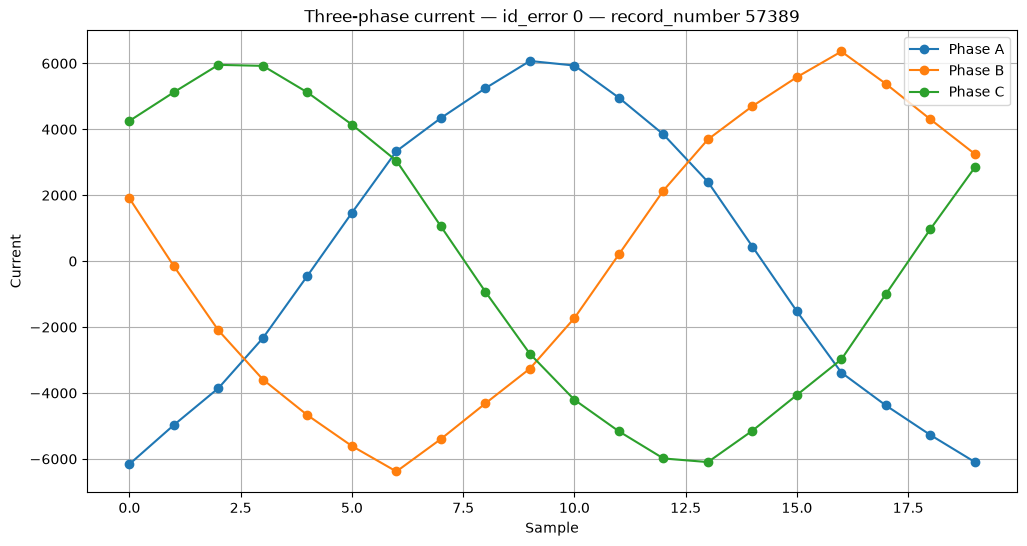

In [5]:
AUTO_MODE = True   # Set to True for default input (default=0), False when you want manual input 

#========================================================
# Step 1 — Load the large JSON file once
#========================================================
with open(INPUT_FILE, "r") as f:
    records = json.load(f)

#========================================================
# Step 2 — Ask user for id_error class
#========================================================
if AUTO_MODE:
    TARGET_ERROR = 0
else:
    user_input = input("Enter id_error to filter by (default = 0): ").strip()
    TARGET_ERROR = int(user_input) if user_input else 0


# Filter records by id_error, keeping index
filtered = [(i, rc) for i, rc in enumerate(records) if rc["id_error"] == TARGET_ERROR]

if not filtered:
    print(f"No records found with id_error = {TARGET_ERROR}")
    exit()

# Pick one record at random
ep_index, record = random.choice(filtered)

print("record_number:", ep_index)
print("Selected id_error:", record["id_error"])

#========================================================
# Step 3 — Extract raw samples
#========================================================
raw = np.array(record["mea_value"])
print("Length:", len(raw))
print("First 15 samples:", raw[:15])

#========================================================
# Step 4 — Extract the three phases
#========================================================
INTERLEAVED = False

if INTERLEAVED:
    phases = raw.reshape(-1, 3).T
    phaseA, phaseB, phaseC = phases
else:
    N = len(raw) // 3
    phaseA = raw[0:N]
    phaseB = raw[N:2*N]
    phaseC = raw[2*N:3*N]

#========================================================
# Step 5 — Plot
#========================================================
plt.figure(figsize=(12, 6))

plt.plot(phaseA, label="Phase A", marker="o", markevery=1)
plt.plot(phaseB, label="Phase B", marker="o", markevery=1)
plt.plot(phaseC, label="Phase C", marker="o", markevery=1)

plt.title(
    f"Three-phase current — id_error {record['id_error']} — record_number {ep_index}"
)
plt.xlabel("Sample")
plt.ylabel("Current")
plt.grid(True)
plt.legend()
plt.show()


### Record Splitting Workflow: Safety Checks and JSON File Generation

In [6]:
# ---------------------------------------------------------
# FLAGS
# ---------------------------------------------------------------------------------------------
RUN_SPLIT = True        # Set to True when you want to run the splitter, False otherwise
FORCE = True            # Set to True to overwrite existing 'records' folder, False otherwise
# ---------------------------------------------------------------------------------------------

if RUN_SPLIT:

    # Check if records directory contains files
    has_content = any(RECORDS_DIR.iterdir())

    # Safety check: prevent accidental overwrite
    if has_content and not FORCE:
        print(f"Folder '{RECORDS_DIR}' already contains files. Set FORCE=True to overwrite.")
    else:
        # Overwrite only if FORCE=True and folder has content
        if FORCE and has_content:
            shutil.rmtree(RECORDS_DIR)
            RECORDS_DIR.mkdir(parents=True, exist_ok=True)


        # Load the giant JSON file
        with open(INPUT_FILE, "rb") as f:
            data = orjson.loads(f.read())

        print(f"Loaded {len(data)} records. Splitting...")

        # Split into individual record files
        for i, record in enumerate(data, start=1):
            out_path = RECORDS_DIR / f"record_{i}.json"
            with open(out_path, "wb") as out:
                out.write(orjson.dumps(record, option=orjson.OPT_INDENT_2))

            if i % 50000 == 0:
                print(f"  → {i} records written...")

        print("Splitting complete.")
else:
    print("Skipping splitting step.")


Loaded 386705 records. Splitting...
  → 50000 records written...
  → 100000 records written...
  → 150000 records written...
  → 200000 records written...
  → 250000 records written...
  → 300000 records written...
  → 350000 records written...
Splitting complete.


### Load and Visualize a Single Record JSON File

Loaded: record_1.json
id_error: 0
Length: 60
First 15 samples: [ 1357.48718262   836.62219238   198.27580261  -433.45697021
 -1021.69415283 -1487.88562012 -1827.92773438 -1999.29748535
 -1964.67578125 -1742.7232666  -1340.88623047  -824.18884277
  -205.68986511   418.98550415  1010.67987061]


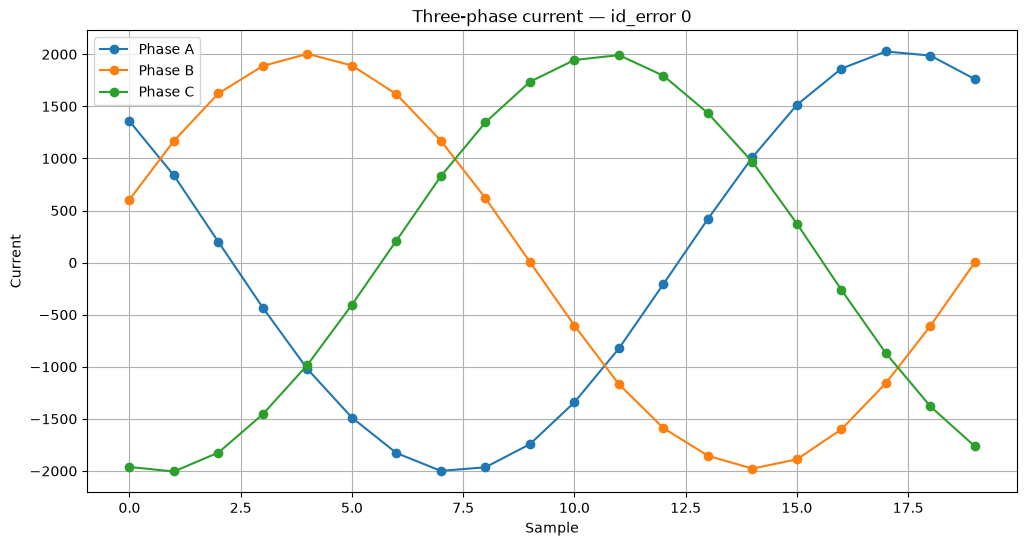

In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

AUTO_MODE = True   # Set to False when you want manual input

#========================================================
# Step 1 — Select and load an record by filename number
#--------------------------------------------------------
# Filenames follow the pattern: episode_1.json, episode_2.json, ...
# So we construct the filename directly from the number the user chooses.
#========================================================

if AUTO_MODE:
    RC_NUMBER = 1
else:
    user_input = input("Enter record number (default = 1): ").strip()
    RC_NUMBER = int(user_input) if user_input else 1

# Construct the filename explicitly
chosen_file = f"record_{RC_NUMBER}.json"
path = os.path.join(RECORDS_DIR, chosen_file)

with open(path, "r") as f:
    record = json.load(f)

print("Loaded:", chosen_file)
print("id_error:", record["id_error"])

#========================================================
# Step 2 — Inspect the first few samples
#--------------------------------------------------------
raw = np.array(record["mea_value"])
print("Length:", len(raw))
print("First 15 samples:", raw[:15])


#========================================================
# Step 3 — Extract the three phases
#--------------------------------------------------------
INTERLEAVED = False

if INTERLEAVED:
    phases = raw.reshape(-1, 3).T
    phaseA, phaseB, phaseC = phases
else:
    N = len(raw) // 3
    phaseA = raw[0:N]
    phaseB = raw[N:2*N]
    phaseC = raw[2*N:3*N]


#========================================================
# Step 4 — Plot the three phases
#--------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(phaseA, label="Phase A", marker="o", markevery=1)
plt.plot(phaseB, label="Phase B", marker="o", markevery=1)
plt.plot(phaseC, label="Phase C", marker="o", markevery=1)

plt.title(f"Three-phase current — id_error {record['id_error']}")
plt.xlabel("Sample")
plt.ylabel("Current")
plt.grid(True)
plt.legend()
plt.show()

### Function for Validation Check and Episode Construction from JSON Dataset

In [8]:
def check_episode_pattern(json_path):
    # Load entire dataset
    with open(json_path, "r") as f:
        records = json.load(f)

    # Sort by timestamp to ensure temporal order
    records = sorted(records, key=lambda r: r["timestamp"])

    episodes = []
    current_episode = [records[0]]

    # Iterate through all records pairwise
    for prev, curr in zip(records, records[1:]):
        same_error = curr["id_error"] == prev["id_error"]
        same_device = curr["device"] == prev["device"]
        same_experiment = curr["experiment_id"] == prev["experiment_id"]
        increasing_time = curr["timestamp"] > prev["timestamp"]

        # Continue episode only if ALL conditions match
        if same_error and same_device and same_experiment and increasing_time:
            current_episode.append(curr)
        else:
            # Episode ended — store it
            episodes.append(current_episode)
            current_episode = [curr]

    # Add the last episode
    episodes.append(current_episode)

    # Validate episodes
    errors = []
    for idx, ep in enumerate(episodes):
        error_values = {r["id_error"] for r in ep}
        device_values = {r["device"] for r in ep}
        experiment_values = {r["experiment_id"] for r in ep}
        timestamps = [r["timestamp"] for r in ep]

        if len(error_values) != 1:
            errors.append(f"Episode {idx}: multiple id_error values {error_values}")

        if len(device_values) != 1:
            errors.append(f"Episode {idx}: multiple devices {device_values}")

        if len(experiment_values) != 1:
            errors.append(f"Episode {idx}: multiple experiment_id values {experiment_values}")

        if timestamps != sorted(timestamps):
            errors.append(f"Episode {idx}: timestamps not strictly increasing")

    print(f"Total records: {len(records)}")
    print(f"Total episodes detected: {len(episodes)}")

    if errors:
        print("\n❌ Violations found:")
        for e in errors:
            print(" -", e)
    else:
        print("\n✔ All episodes match the definition perfectly.")

    return episodes, errors


### Function for Saving Episodes as Individual JSON Files

In [11]:
def save_episodes(episodes, output_dir):
    for i, ep in enumerate(episodes, start=1):
        ep_path = output_dir / f"episode_{i:04d}.json"
        with open(ep_path, "wb") as out:
            out.write(orjson.dumps(ep, option=orjson.OPT_INDENT_2))

        # Optional progress indicator
        if i % 5000 == 0:
            print(f"  → {i} episodes written...")

    print(f"Saved {len(episodes)} episodes to: {output_dir}")


### Episode Splitting Workflow: Safety Checks, Validation, and Export

In [12]:
# ---------------------------------------------------------
# FLAGS
# --------------------------------------------------------------------------------------------------
RUN_SPLIT_EPISODES = True  # Set True to run episode splitter, False otherwise
FORCE = True                 # Set True to overwrite existing 'episodes' folder, False otherwise
# --------------------------------------------------------------------------------------------------

if RUN_SPLIT_EPISODES:

    has_content = any(EPISODES_DIR.iterdir())

    if has_content and not FORCE:
        print(f"Folder '{EPISODES_DIR}' already contains files. Set FORCE=True to overwrite.")

    else:
        if FORCE and has_content:
            shutil.rmtree(EPISODES_DIR)
            EPISODES_DIR.mkdir(parents=True, exist_ok=True)

        episodes, errors = check_episode_pattern(INPUT_FILE)

        if errors:
            print("❌ Episodes not saved due to validation errors.")
            for e in errors:
                print(" -", e)

        else:
            print(f"✔ Dataset valid. Saving {len(episodes)} episodes...")
            save_episodes(episodes, EPISODES_DIR)
            print("Episode splitting complete.")
else:
    print("Skipping episode splitting step.")


Total records: 386705
Total episodes detected: 33627

✔ All episodes match the definition perfectly.
✔ Dataset valid. Saving 33627 episodes...
  → 5000 episodes written...
  → 10000 episodes written...
  → 15000 episodes written...
  → 20000 episodes written...
  → 25000 episodes written...
  → 30000 episodes written...
Saved 33627 episodes to: c:\Users\paude\OneDrive\Documents\@Schools_Learning\@HarvardExtension\2026FALL\CSCIE115APDS26FA\converter-iq-mlops\ml\data\raw_episodes
Episode splitting complete.
